# Théo FERNANDO

# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn import metrics
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Récupérer les données


In [ ]:
train_set = pd.read_csv('train.csv')
test_set = pd.read_csv('test.csv')

# 2.1 - Préparation des données


## Visualisation

In [ ]:
train_set.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


On se donne un aperçu des 5 premières lignes du jeu de données.

In [ ]:
train_set.info() # Vérifier qu'il existe ou non des données nulles

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB


**Remarque :** Le dataset se compose de 7532 entrées avec 563 colonnes qui représentent les différentes données de l'appareil notamment le gyroscope, la position, l'accélération...

In [ ]:
train_set['Activity'].value_counts()

,count
Activity,
LAYING,1407
STANDING,1374
SITTING,1286
WALKING,1226
WALKING_UPSTAIRS,1073
WALKING_DOWNSTAIRS,986


**Remarque :** Les données sont plutôt équilibrées, il n'y a pas de différence importante notable entre les valeurs.

## Suppression de la variable "subject"

In [ ]:
train_set = train_set.drop("subject", axis=1)
test_set = test_set.drop("subject", axis=1)

L'ajout de nouvelles variables n'est pas nécessaire car il y a déjà un grand nombre de caractéristiques pour définir les données

## Transformation de la variable "Activity" en numérique

In [ ]:
mapping = {
    'WALKING': 0, 'STANDING': 1, 'LAYING': 2,
    'WALKING_UPSTAIRS': 3, 'SITTING': 4, 'WALKING_DOWNSTAIRS': 5
}
train_set['Activity'] = train_set['Activity'].map(mapping)
test_set['Activity'] = test_set['Activity'].map(mapping)

In [ ]:
train_set.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1


**Remarque :** La colonne "Activity" possède bien des chiffres.

## Séparation des prédicteurs (X) et de la cible (Y)

In [ ]:
X_train = train_set.drop("Activity", axis=1)
y_train = train_set["Activity"].copy()
X_test = test_set.drop("Activity", axis=1)
y_test = test_set["Activity"].copy()

# 2.9 Pipeline


In [ ]:
model_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [ ]:
X_train_prepare = model_pipeline.fit_transform(X_train)
X_test_prepare = model_pipeline.transform(X_test)

# 2.2 Validation croisée k = 3 & 2.3 Mesures des métriques précision, rappel et f-score

## Decision Tree

In [ ]:
# Decision tree
dtc = DecisionTreeClassifier(criterion="entropy", random_state=42)
# Validation croisée
cross_val_scores_dtc = cross_val_score(dtc, X_train_prepare, y_train, cv=3, scoring='accuracy')
# Validation croisée avec prédiction
y_pred_dtc = cross_val_predict(dtc, X_train_prepare, y_train, cv=3)
# Affichage des résultats
print(metrics.classification_report(y_train, y_pred_dtc))



              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1226
           1       0.88      0.85      0.86      1374
           2       0.99      0.99      0.99      1407
           3       0.87      0.68      0.76      1073
           4       0.83      0.87      0.85      1286
           5       0.78      0.88      0.83       986

    accuracy                           0.86      7352
   macro avg       0.86      0.86      0.86      7352
weighted avg       0.87      0.86      0.86      7352



**Remarque** : Le F1-score est plutôt bon pour ce modèle.


## Random Forest

In [ ]:
# Random Forest
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
# Validation croisée
cross_val_scores_rfc = cross_val_score(rfc, X_train_prepare, y_train, cv=3, scoring='accuracy')
# Validation croisée avec prédiction
y_pred_rfc = cross_val_predict(rfc, X_train_prepare, y_train, cv=3)
# Affichage des résultats
print(metrics.classification_report(y_train, y_pred_rfc))


              precision    recall  f1-score   support

           0       0.95      0.87      0.91      1226
           1       0.88      0.90      0.89      1374
           2       0.99      1.00      0.99      1407
           3       0.82      0.92      0.87      1073
           4       0.89      0.88      0.89      1286
           5       0.91      0.87      0.89       986

    accuracy                           0.91      7352
   macro avg       0.91      0.91      0.91      7352
weighted avg       0.91      0.91      0.91      7352



**Remarque** : Le F1-score est excellent.


## XGBoost


In [ ]:
# XGBoost
xgb = XGBClassifier(random_state=42)
# Validation croisée
cross_val_scores_xgb = cross_val_score(xgb, X_train_prepare, y_train, cv=3, scoring='accuracy')
# Validation croisée avec prédiction
y_pred_xgb = cross_val_predict(xgb, X_train_prepare, y_train, cv=3)
# Affichage des résultats
print(metrics.classification_report(y_train, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1226
           1       0.90      0.90      0.90      1374
           2       0.98      1.00      0.99      1407
           3       0.86      0.88      0.87      1073
           4       0.89      0.86      0.88      1286
           5       0.90      0.90      0.90       986

    accuracy                           0.91      7352
   macro avg       0.91      0.91      0.91      7352
weighted avg       0.91      0.91      0.91      7352



Remarque : Le F1-score de Random Forest et de XGBoost sont identiques, ce qui amènerait à penser que leurs performances sont similaires pour ce dataset.

# 2.4 Optimisation avec les hyperparamètres

## Decision tree

In [ ]:
print("Optimisation du Decision Tree...")
param_grid_dt = {
    'max_depth': list(range(2, 20)),
    'min_samples_split': [5, 10, 15],
    'max_features': ['sqrt', 'log2']
}
#Changer le scoring ?
dt_grid = GridSearchCV(DecisionTreeClassifier(criterion="entropy", random_state=42),
                       param_grid_dt, cv=3, n_jobs=-1)
dt_grid.fit(X_train_prepare, y_train)
best_dt = dt_grid.best_estimator_
print(f"Meilleurs paramètres DT : {dt_grid.best_params_}")

Optimisation du Decision Tree...
Meilleurs paramètres DT : {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 5}


## Random Forest

In [ ]:
print("Optimisation de la Random Forest...")
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20],
    'max_features': ['sqrt', 'log2']
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid_rf, cv=3, n_jobs=-1)
rf_grid.fit(X_train_prepare, y_train)
best_rf = rf_grid.best_estimator_
print(f"Meilleurs paramètres RF : {rf_grid.best_params_}")

Optimisation de la Random Forest...
Meilleurs paramètres RF : {'max_depth': 10, 'max_features': 'log2', 'n_estimators': 200}


## XGBoost

In [ ]:
print("Optimisation de XGBoost...")
param_grid_xgb = {
    'n_estimators': [1050, 1100, 1150 ],
    'learning_rate': [0.01, 0.1],
    'max_depth': [2, 6]
}
xgb_model = XGBClassifier(tree_method='hist', device='cuda', random_state=42)
xgb_grid = GridSearchCV(xgb_model, param_grid_xgb, cv=3)
xgb_grid.fit(X_train_prepare, y_train)
best_xgb = xgb_grid.best_estimator_
print(f"Meilleurs paramètres XGB : {xgb_grid.best_params_}")

Optimisation de XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [21:21:24] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Meilleurs paramètres XGB : {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 1100}


## Meilleurs scores

In [ ]:
# Étape 2.4 (fin) : Comparaison des scores d'optimisation
scores_optimises = {
    "Decision Tree": dt_grid.best_score_,
    "Random Forest": rf_grid.best_score_,
    "XGBoost": xgb_grid.best_score_
}

# Trouver le nom du modèle avec le score F1 le plus élevé
meilleur_nom = max(scores_optimises, key=scores_optimises.get)
meilleur_score = scores_optimises[meilleur_nom]

print("--- COMPARAISON DES MODÈLES OPTIMISÉS ---")
for modele, score in scores_optimises.items():
    print(f"{modele} : F1-Score = {score:.4f}")

print(f"\n=> Le MEILLEUR MODÈLE est : {meilleur_nom} ({meilleur_score:.4f})")

--- COMPARAISON DES MODÈLES OPTIMISÉS ---
Decision Tree : F1-Score = 0.8183
Random Forest : F1-Score = 0.9271
XGBoost : F1-Score = 0.9291

=> Le MEILLEUR MODÈLE est : XGBoost (0.9291)


**Remarque :** Après un réglage précis des hyperparamètres, nous pouvons remarquer que le modèle XGBoost dépasse à peine les performances du modèle de Random Forest. C'est donc celui-ci que nous allons utiliser pour la suite.

# 2.5 Test du meilleur modèle

## Meilleur Decision Tree

In [33]:
final_model_dt = best_dt

y_pred_final_dt = final_model_dt.predict(X_test_prepare)

print("--- PERFORMANCES SUR LE JEU DE TEST (FINAL) ---")

# On génère le rapport.
# 'target_names' permet d'afficher 'WALKING', 'SITTING', etc., au lieu de 0, 1, 2...
report_final_dt = classification_report(y_test, y_pred_final_dt, target_names=list(mapping.keys()))

print(report_final_dt)

--- PERFORMANCES SUR LE JEU DE TEST (FINAL) ---
                    precision    recall  f1-score   support

           WALKING       0.78      0.89      0.83       496
          STANDING       0.79      0.84      0.81       532
            LAYING       1.00      0.97      0.98       537
  WALKING_UPSTAIRS       0.74      0.69      0.71       471
           SITTING       0.79      0.75      0.77       491
WALKING_DOWNSTAIRS       0.83      0.75      0.79       420

          accuracy                           0.82      2947
         macro avg       0.82      0.82      0.82      2947
      weighted avg       0.82      0.82      0.82      2947



## Meilleur Random Forest

In [32]:
final_model_rf = best_rf

y_pred_final_rf = final_model_rf.predict(X_test_prepare)

print("--- PERFORMANCES SUR LE JEU DE TEST (FINAL) ---")

# On génère le rapport.
# 'target_names' permet d'afficher 'WALKING', 'SITTING', etc., au lieu de 0, 1, 2...
report_final_rf = classification_report(y_test, y_pred_final_rf, target_names=list(mapping.keys()))

print(report_final_rf)

--- PERFORMANCES SUR LE JEU DE TEST (FINAL) ---
                    precision    recall  f1-score   support

           WALKING       0.91      0.97      0.94       496
          STANDING       0.87      0.98      0.92       532
            LAYING       1.00      1.00      1.00       537
  WALKING_UPSTAIRS       0.90      0.94      0.92       471
           SITTING       0.98      0.85      0.91       491
WALKING_DOWNSTAIRS       0.96      0.84      0.89       420

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



## Meilleur XGBoost

In [ ]:
final_model = best_xgb

y_pred_final = final_model.predict(X_test_prepare)

print("--- PERFORMANCES SUR LE JEU DE TEST (FINAL) ---")

# On génère le rapport.
# 'target_names' permet d'afficher 'WALKING', 'SITTING', etc., au lieu de 0, 1, 2...
report_final = classification_report(y_test, y_pred_final, target_names=list(mapping.keys()))

print(report_final)

--- PERFORMANCES SUR LE JEU DE TEST (FINAL) ---
                    precision    recall  f1-score   support

           WALKING       0.94      0.98      0.96       496
          STANDING       0.91      0.98      0.94       532
            LAYING       1.00      1.00      1.00       537
  WALKING_UPSTAIRS       0.94      0.93      0.94       471
           SITTING       0.97      0.89      0.93       491
WALKING_DOWNSTAIRS       0.98      0.95      0.96       420

          accuracy                           0.96      2947
         macro avg       0.96      0.95      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



# 2.6 Affichage des résultats


In [ ]:
# 1. Calcul de la matrice de base
cm = confusion_matrix(y_test, y_pred_final)
labels_display = ['WK', 'SD', 'LD', 'WU', 'ST', 'WD'] # Raccourcis style article
labels_full = list(mapping.keys())

# 2. Création du DataFrame de base
df_cm = pd.DataFrame(cm, index=labels_full, columns=labels_display)

# 3. Calcul du Recall (Rappel) par ligne
# Rappel = Vrais Positifs / Total de la ligne
recall = np.diag(cm) / np.sum(cm, axis=1)
df_cm['Recall'] = [f"{r:.0%}" for r in recall]

# 4. Calcul de la Precision par colonne
# Précision = Vrais Positifs / Total de la colonne
precision = np.diag(cm) / np.sum(cm, axis=0)
precision_row = [f"{p:.0%}" for p in precision] + [f"{np.mean(precision):.0%}"]

# 5. Ajout de la ligne de précision finale
df_cm.loc['Precision'] = precision_row

print("--- Tableau de synthèse des performances (Style Table 1) ---")
display(df_cm)

--- Tableau de synthèse des performances (Style Table 1) ---


,WK,SD,LD,WU,ST,WD,Recall
WALKING,486,0,0,7,0,3,98%
STANDING,0,519,0,0,13,0,98%
LAYING,0,0,537,0,0,0,100%
WALKING_UPSTAIRS,28,0,0,438,0,5,93%
SITTING,0,51,0,3,437,0,89%
WALKING_DOWNSTAIRS,5,0,0,16,0,399,95%
Precision,94%,91%,100%,94%,97%,98%,96%


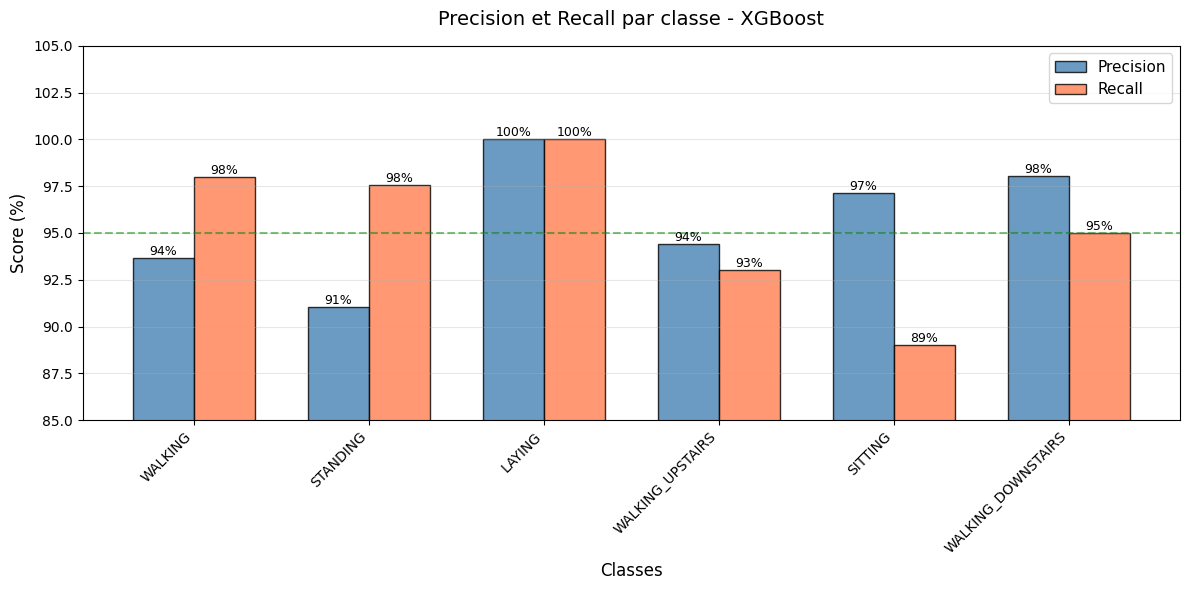


📊 Observations :
- Meilleure classe : LAYING (Recall: 100.0%)
- Classe la plus difficile : SITTING (Recall: 89.0%)


In [35]:
# === COMPARAISON PRECISION / RECALL PAR CLASSE ===
fig, ax = plt.subplots(figsize=(12, 6))

classes = labels_full
x = np.arange(len(classes))
width = 0.35

recall_values = recall * 100
precision_values = precision * 100

bars1 = ax.bar(x - width/2, precision_values, width, label='Precision',
               alpha=0.8, color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, recall_values, width, label='Recall',
               alpha=0.8, color='coral', edgecolor='black')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}%',
                ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Classes', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Precision et Recall par classe - XGBoost', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.set_ylim([85, 105])
ax.axhline(y=95, color='green', linestyle='--', alpha=0.5, label='Seuil 95%')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Observations :")
print(f"- Meilleure classe : {classes[np.argmax(recall_values)]} (Recall: {max(recall_values):.1f}%)")
print(f"- Classe la plus difficile : {classes[np.argmin(recall_values)]} (Recall: {min(recall_values):.1f}%)")

# 2.7 Analyser et interpréter les résultats obtenus

Tout d'abord, nous pouvons remarquer que le meilleur modèle obtenu est celui de XGBoost avec un f1-score de **96 %** et égalant les perforamnces du SVM et surperformant légèrement celles du Random Forest. Cette performance démontre l'efficacité des modèles d'ensemble pour la reconnaissance d'activités humaines.
- La classe LAYING est parfaitement distinguée avec un score de 100%
- Les classes WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS sont extrêmement bien identifiées.

Les principales sources d'erreurs proviennet de la confusion entre SITTING et STANDING avec 51 erreurs cela provient probablement du fait que ces deux activités sont statiques avec peu de mouvement, les signaux sont probablement très similaires.

Le modèle XGBoost montre des performances excellentes. En effet, il montre des performances similaires entre la validation croisée et le test final, il n'y a pas de signe de sur-apprentissage et le modèle est stable et fiable.


# 2.8 Comparaison des 4 modèles


La comparaison entre les quatre modèles révèle des différences significatives de performance.

Voici le classement des modèles
- SVM (référence) : 96% de F1-score
- XGBoost : 96% de F1-score
- Random Forest : 93% de F1-score
- Decision Tree : 82% de F1-score

Les trois modèles d'ensemble atteignent quasiment tous le même niveau de performance globale avec un F1-score d'environ 96%.

Ce qu'on peut retenir de ce TP est que le Decision Tree est un modèle simple et rapide à entraîner et il peut certainement être efficace dans d'autres domaines.

Le Random Forest est beaucoup plus puissant que le DT sur ce domaine mais il est également très long et complexe à paramétrer car l'entraînement est fastidieux.

De ce que j'ai pu observé, le XGBoost est légèrement plus rapide à entraîner que le Random Forest mais il est également plus performant ce qui en fait le meilleur modèle de ce TP parmi les modèles que nous avons entraînés.

Ce qu'on peut retenir est que le passage d'un modèle simple (Decisiont Tree) à des modèles d'ensemble à permis un gain de performance d'environ 14%. La complexité des mouvements humains nécessitent des modèles sophistiqués avec une multitude d'arbres. A noter que tous les modèles sous-performent pour différencier SITTING et STANDING.

On peut donc conclure que le meilleur modèle est celui de XGBoost car il permet un gain de performance comparé aux autres modèles du fait de sa robustesse et de sa capacité à gérer efficacement un grand nombre de colonnes de données.

## Comparaison graphique

,Modèle,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
0,Decision Tree,0.82,0.82,0.82,0.82
1,Random Forest,0.93,0.94,0.93,0.93
2,XGBoost,0.96,0.96,0.95,0.96
3,SVM (référence),0.96,0.96,0.96,0.96


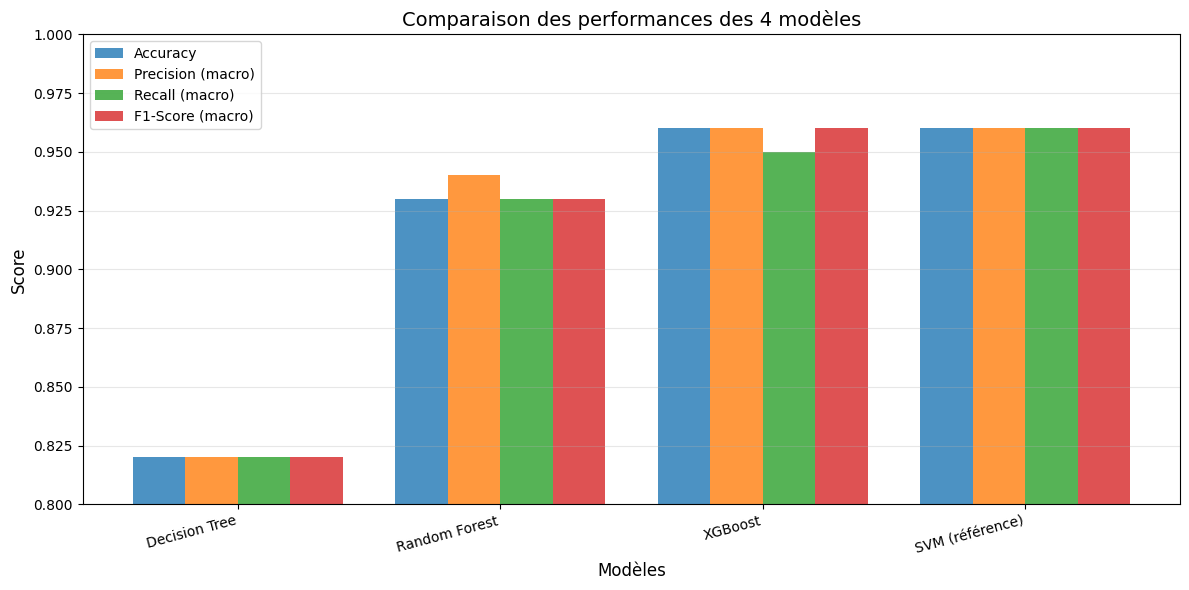

In [34]:
# === VERSION SIMPLIFIÉE AVEC VALEURS MANUELLES ===
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Créer directement le DataFrame avec vos valeurs
# REMPLACEZ ces valeurs par celles de vos vrais résultats !
results_comparison = pd.DataFrame({
    'Modèle': ['Decision Tree', 'Random Forest', 'XGBoost', 'SVM (référence)'],
    'Accuracy': [0.82, 0.93, 0.96, 0.96],  # ← CHANGEZ ces valeurs
    'Precision (macro)': [0.82, 0.94, 0.96, 0.96],  # ← CHANGEZ ces valeurs
    'Recall (macro)': [0.82, 0.93, 0.95, 0.96],  # ← CHANGEZ ces valeurs
    'F1-Score (macro)': [0.82, 0.93, 0.96, 0.96]  # ← CHANGEZ ces valeurs
})

display(results_comparison)

# Graphique
fig, ax = plt.subplots(figsize=(12, 6))

models = results_comparison['Modèle']
metrics_to_plot = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']

x = np.arange(len(models))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    values = results_comparison[metric]
    ax.bar(x + i*width, values, width, label=metric, alpha=0.8)

ax.set_xlabel('Modèles', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des performances des 4 modèles', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend()
ax.set_ylim([0.8, 1.0])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()